# Handwritten character recognition with CNN

## Importing and preparing data


In [1]:
!git lfs pull

In [55]:
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential, Model, load_model
from keras.layers import Dense, Flatten
from keras.layers import Conv2D, MaxPooling2D, Dropout, BatchNormalization, AveragePooling2D
from keras.utils import to_categorical
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import random
from sklearn.metrics import confusion_matrix

In [3]:
df = pd.read_csv('data.csv', header=None, dtype='uint8') 

In [4]:
y_raw = df.iloc[:, 0].values
y = to_categorical(y_raw, num_classes=26)
X = df.iloc[:, 1:].values
X = X.reshape(372451, 28, 28)
X = X.astype(np.float32) / 255.0
del df

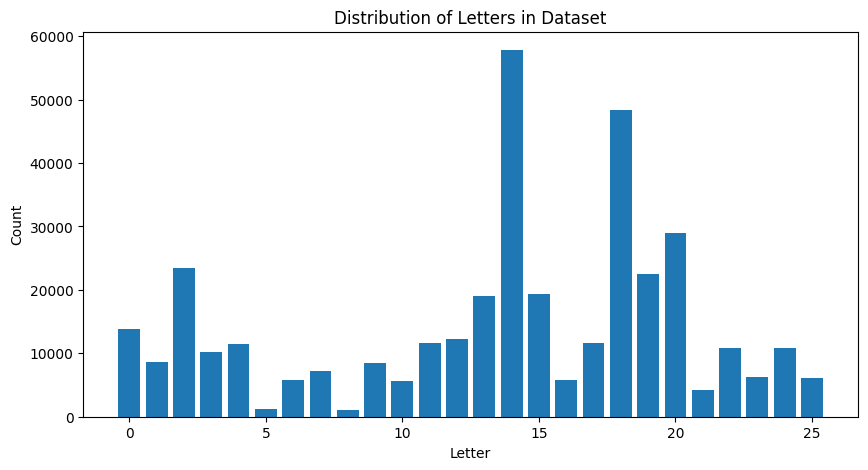

In [5]:
hist = np.histogram(y_raw, bins=26)
hist = hist[0]
plt.figure(figsize=(10, 5))
plt.bar(np.arange(26), hist)
plt.xlabel('Letter')
plt.ylabel('Count')
plt.title('Distribution of Letters in Dataset')
plt.show()

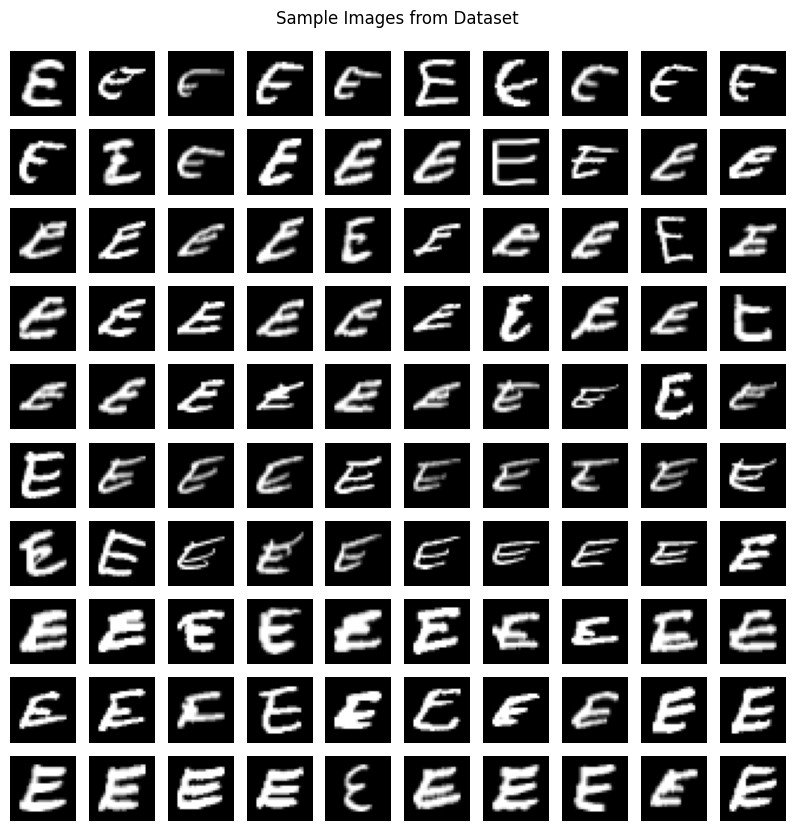

In [6]:
plt.figure(figsize=(10, 10))
plt.title('Sample Images from Dataset', pad=20)
plt.axis('off')
for i in range(100):
    plt.subplot(10, 10, i + 1)
    plt.imshow(X[y_raw == 4][i+100], cmap='gray')
    #plt.title(chr(i + 65))
    plt.axis('off')

In [7]:
def normalize_z_score(batch):
    """
    Standardizes each image in a (N, Height, Width) batch to Mean=0, Std=1.
    """
    # 1. Calculate Mean and Standard Deviation per image
    means = batch.mean(axis=(1, 2), keepdims=True)
    stds = batch.std(axis=(1, 2), keepdims=True)
    
    epsilon = 1e-7
    
    # 2. Apply the Z-score formula: (x - mean) / std
    standardized_batch = (batch - means) / (stds + epsilon)
    
    return standardized_batch
X = normalize_z_score(X)

In [8]:
X_train, y_train = np.load('data.npz').values()
y_train = to_categorical(y_train, num_classes=26)

In [9]:
X_val, X_test, y_val, y_test = train_test_split(
    X, 
    y_raw, 
    test_size=0.15,      # 20% goes to the test set, 80% to the val set
    random_state=42,     # Sets a seed so you get the exact same split every time
    stratify=y_raw # CRITICAL FOR CLASSIFICATION
)
y_test = to_categorical(y_test, num_classes=26)
y_val = to_categorical(y_val, num_classes=26)

In [10]:
del X, y, y_raw

## Smaller model

In [ ]:
early_stopper = EarlyStopping(
    monitor='val_loss',         # Watch the validation loss
    mode='min',                 # We want the loss to go down (minimize)
    patience=5,                 # Wait 5 epochs before giving up
    restore_best_weights=True   # CRITICAL: Rewind to the best epoch when done!
)

# 2. The Disk Saver: Saves the physical file
disk_saver1 = ModelCheckpoint(
    filepath='small.keras', # Name of the file to save
    monitor='val_loss',                      # Must match what EarlyStopping is watching
    mode='min',                              # We want the loss to go down
    save_best_only=True,                     # CRITICAL: Only overwrite if it's a new record
    verbose=1                                # Prints a message when a new record is saved
)
disk_saver2 = ModelCheckpoint(
    filepath='big.keras', # Name of the file to save
    monitor='val_loss',                      # Must match what EarlyStopping is watching
    mode='min',                              # We want the loss to go down
    save_best_only=True,                     # CRITICAL: Only overwrite if it's a new record
    verbose=1                                # Prints a message when a new record is saved
)

In [62]:
classifier = Sequential()
classifier.add(Conv2D(16, (3, 3), padding='same', activation='relu', input_shape=(28, 28,1)))
#classifier.add(Conv2D(32, (3, 3), padding='same', activation='relu'))

classifier.add(MaxPooling2D(pool_size=(2, 2)))
classifier.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
classifier.add(Dropout(0.25))
classifier.add(MaxPooling2D(pool_size=(2, 2)))
classifier.add(Conv2D(32, (3, 3), padding='same', activation='relu'))
classifier.add(MaxPooling2D(pool_size=(2, 2)))
classifier.add(Dropout(0.25))
classifier.add(Flatten())

classifier.add(Dense(64, activation='relu'))
classifier.add(Dropout(0.4))
classifier.add(Dense(64, activation='relu'))
classifier.add(Dropout(0.4))
classifier.add(Dense(26, activation='softmax'))

classifier.summary()
classifier.compile(optimizer = 'adam', loss = 'categorical_crossentropy',  metrics = ['accuracy'])

C:\Users\milan\AppData\Roaming\Python\Python39\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_27 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_28 (Conv2D)              │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_33 (Dropout)            │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_29 (Conv2D)              │ (None, 7, 7, 32)       │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_34 (Dropout)            │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 64)             │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_35 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_29 (Dense)                │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_36 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_30 (Dense)                │ (None, 26)             │         1,690 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 38,394 (149.98 KB)

 Trainable params: 38,394 (149.98 KB)

 Non-trainable params: 0 (0.00 B)

In [64]:
history = classifier.fit(X_train, y_train, batch_size=128, epochs=50, verbose=1, validation_data=(X_test, y_test), callbacks=[early_stopper, disk_saver1])

Epoch 1/50
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8713 - loss: 0.4192
Epoch 1: val_loss did not improve from 1.40774
220/220 ━━━━━━━━━━━━━━━━━━━━ 8s 39ms/step - accuracy: 0.8713 - loss: 0.4192 - val_accuracy: 0.5607 - val_loss: 1.4195
Epoch 2/50
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.8786 - loss: 0.4027
Epoch 2: val_loss did not improve from 1.40774
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 48ms/step - accuracy: 0.8786 - loss: 0.4027 - val_accuracy: 0.5422 - val_loss: 1.5188
Epoch 3/50
220/220 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.8883 - loss: 0.3700
Epoch 3: val_loss did not improve from 1.40774
220/220 ━━━━━━━━━━━━━━━━━━━━ 12s 52ms/step - accuracy: 0.8883 - loss: 0.3700 - val_accuracy: 0.5658 - val_loss: 1.4364
Epoch 4/50
219/220 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step - accuracy: 0.8875 - loss: 0.3644
Epoch 4: val_loss did not improve from 1.40774
220/220 ━━━━━━━━━━━━━━━━━━━━ 11s 49ms/step - accuracy: 0.8875 - loss: 0.3644 - val_accuracy: 0.5534 - val_lo

In [65]:
small = load_model('small.keras')
loss, accuracy = small.evaluate(X_val, y_val)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

9894/9894 ━━━━━━━━━━━━━━━━━━━━ 62s 6ms/step - accuracy: 0.6050 - loss: 1.4046
Test Accuracy: 60.45%


In [66]:
predictions_s_raw = small.predict(X_test)
predictions_s = np.argmax(predictions_s_raw, axis=1)
labels = np.argmax(y_test, axis=1)
del predictions_s_raw


1746/1746 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step


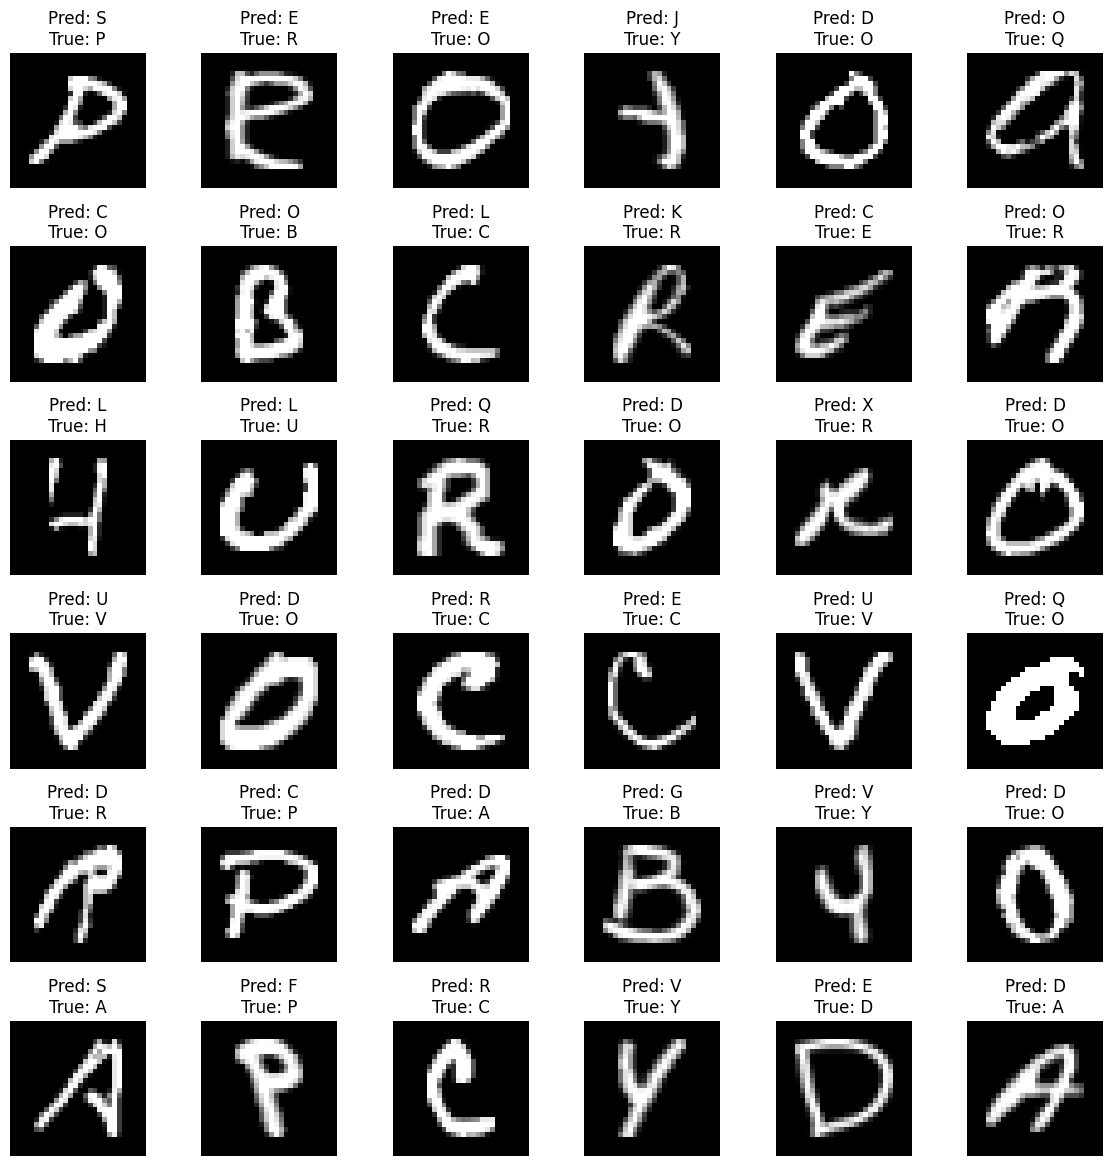

In [79]:
mistakes = np.where(predictions_s != labels)[0]
plt.figure(figsize=(12, 12))
for i in range(36):
    num = random.randint(0, len(mistakes) - 1)
    plt.subplot(6, 6, i + 1)
    plt.imshow(X_test[mistakes[num]].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {chr(predictions_s[mistakes[num]] + 65)}\nTrue: {chr(labels[mistakes[num]] + 65)}")
    plt.tight_layout()
    plt.axis('off')


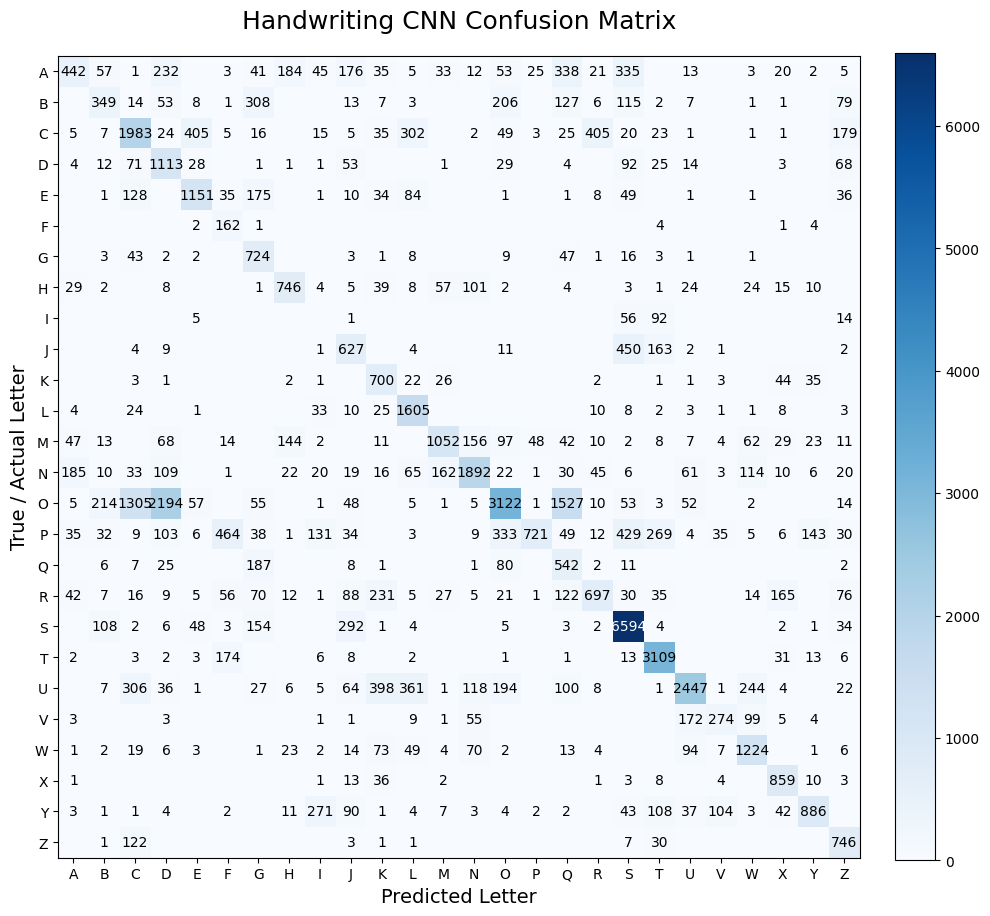

In [68]:
cm = confusion_matrix(labels, predictions_s)

# 2. Set up the figure size
fig, ax = plt.subplots(figsize=(10, 10))

# 3. Draw the heatmap blocks
# cmap=plt.cm.Blues makes it dark blue for high numbers, white for low numbers
cax = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
fig.colorbar(cax, fraction=0.046, pad=0.04) # Adds the color scale on the right

# 4. Set up the A-Z labels on the X and Y axes
classes = [chr(i + 65) for i in range(26)] # Generates ['A', 'B', 'C' ... 'Z']
tick_marks = np.arange(len(classes))

ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# 5. Add the numbers inside the boxes
# We calculate a threshold so we can use white text on dark blue boxes, 
# and black text on light blue boxes for readability.
thresh = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Optional: Only draw the number if it's greater than 0 to keep the grid clean
        if cm[i, j] > 0:
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

# 6. Add the final titles and labels
ax.set_title('Handwriting CNN Confusion Matrix', fontsize=18, pad=20)
ax.set_ylabel('True / Actual Letter', fontsize=14)
ax.set_xlabel('Predicted Letter', fontsize=14)

# 7. Clean up the layout and display
fig.tight_layout()
plt.show()

In [71]:
classifier = Sequential()
classifier.add(Conv2D(32, (3, 3), padding='same', activation='relu', input_shape=(28, 28, 1)))
classifier.add(Dropout(0.25))
classifier.add(MaxPooling2D(pool_size=(2, 2)))

classifier.add(Conv2D(64, (3, 3), padding='same', activation='relu'))
classifier.add(Dropout(0.3))
classifier.add(MaxPooling2D(pool_size=(2, 2)))


classifier.add(Conv2D(128, (3,3), padding='same', input_shape = (7, 7, 1), activation = 'relu'))
classifier.add(Dropout(0.3))
classifier.add(MaxPooling2D(pool_size=(2, 2)))

classifier.add(Flatten())

w1 = Dense(units = 128, activation = 'relu')
w2 = Dense(units = 128, activation = 'relu')
w3 = Dense(units = 26, activation = 'softmax')

classifier.add(w1)
classifier.add(Dropout(0.5)) 
classifier.add(w2)
classifier.add(Dropout(0.5))
classifier.add(w3)

classifier.summary()
classifier.compile(optimizer = 'adam', loss = 'categorical_crossentropy',  metrics = ['accuracy'])

Model: "sequential_14"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_36 (Conv2D)              │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_47 (Dropout)            │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_48 (Dropout)            │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_49 (Dropout)            │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_13 (Flatten)            │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_37 (Dense)                │ (None, 128)            │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_50 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_38 (Dense)                │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_51 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_39 (Dense)                │ (None, 26)             │         3,354 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 260,122 (1016.10 KB)

 Trainable params: 260,122 (1016.10 KB)

 Non-trainable params: 0 (0.00 B)

In [72]:
history = classifier.fit(X_train, y_train, batch_size=64, epochs=50, verbose=1, validation_data=(X_test, y_test), callbacks=[early_stopper, disk_saver2])

Epoch 1/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step - accuracy: 0.1789 - loss: 2.7670
Epoch 1: val_loss improved from inf to 1.79175, saving model to big.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 39s 84ms/step - accuracy: 0.1793 - loss: 2.7656 - val_accuracy: 0.4732 - val_loss: 1.7917
Epoch 2/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.6801 - loss: 0.9715
Epoch 2: val_loss improved from 1.79175 to 1.58876, saving model to big.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 98ms/step - accuracy: 0.6802 - loss: 0.9712 - val_accuracy: 0.5336 - val_loss: 1.5888
Epoch 3/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.8103 - loss: 0.5843
Epoch 3: val_loss improved from 1.58876 to 1.39047, saving model to big.keras
439/439 ━━━━━━━━━━━━━━━━━━━━ 43s 99ms/step - accuracy: 0.8103 - loss: 0.5842 - val_accuracy: 0.5855 - val_loss: 1.3905
Epoch 4/50
439/439 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step - accuracy: 0.8645 - loss: 0.4164
Epoch 4: val_loss improved from 1.39047 to 1.28397, saving model 

In [73]:
big = load_model('big.keras')
loss, accuracy = big.evaluate(X_val, y_val)
print(f"Test Accuracy: {accuracy * 100:.2f}%")

9894/9894 ━━━━━━━━━━━━━━━━━━━━ 153s 15ms/step - accuracy: 0.6235 - loss: 1.2846
Test Accuracy: 62.30%


In [74]:
predictions_b_raw = big.predict(X_test)
predictions_b = np.argmax(predictions_b_raw, axis=1)
labels = np.argmax(y_test, axis=1)
del predictions_b_raw

1746/1746 ━━━━━━━━━━━━━━━━━━━━ 22s 13ms/step


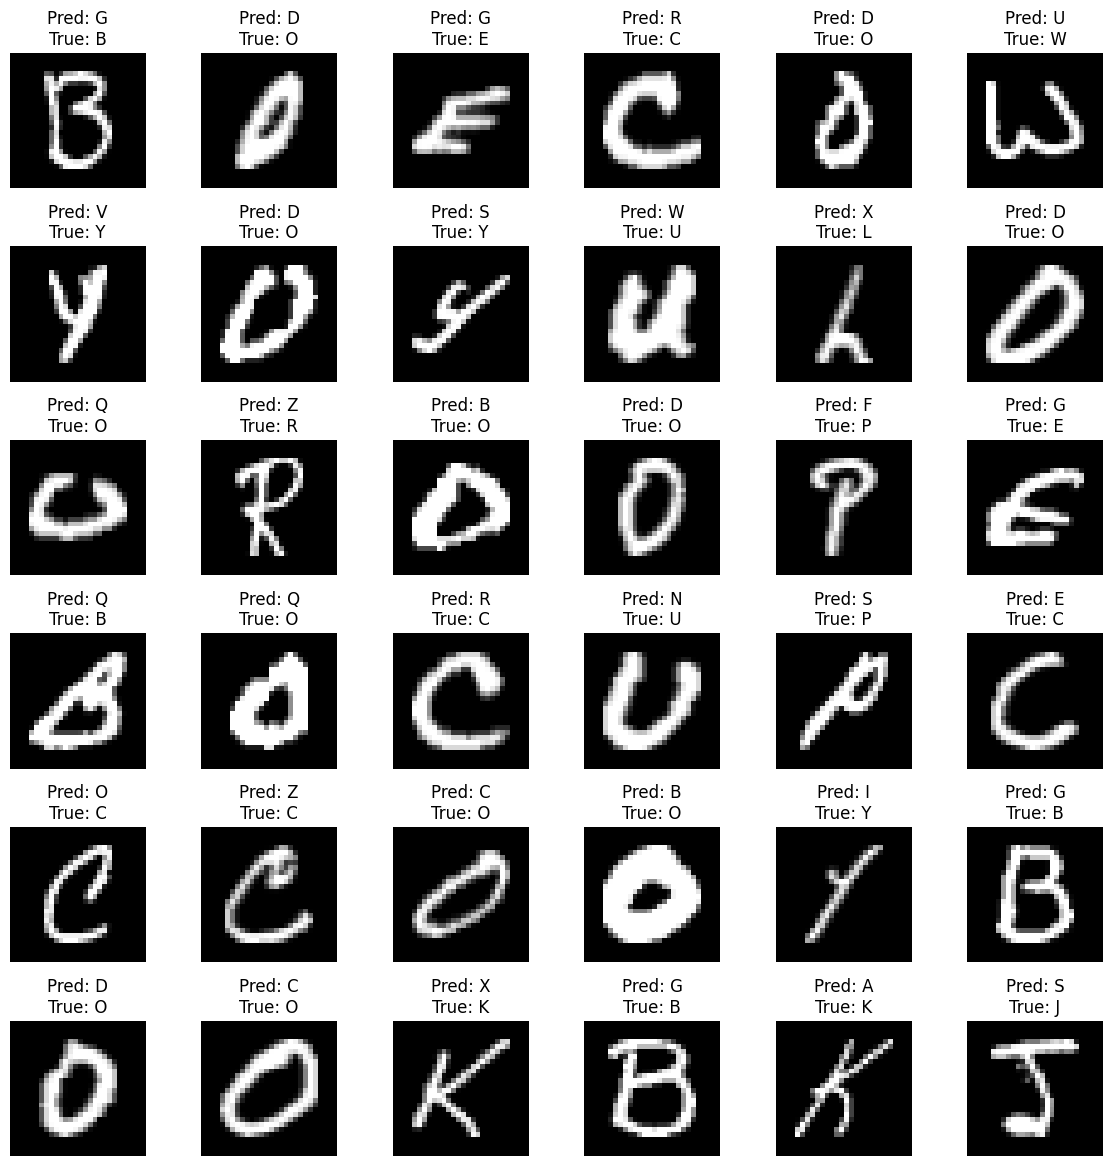

In [80]:
mistakes = np.where(predictions_b != labels)[0]
plt.figure(figsize=(12, 12))
for i in range(36):
    num = random.randint(0, len(mistakes) - 1)
    plt.subplot(6, 6, i + 1)
    plt.imshow(X_test[mistakes[num]].reshape(28, 28), cmap='gray')
    plt.title(f"Pred: {chr(predictions_b[mistakes[num]] + 65)}\nTrue: {chr(labels[mistakes[num]] + 65)}")
    plt.tight_layout()
    plt.axis('off')


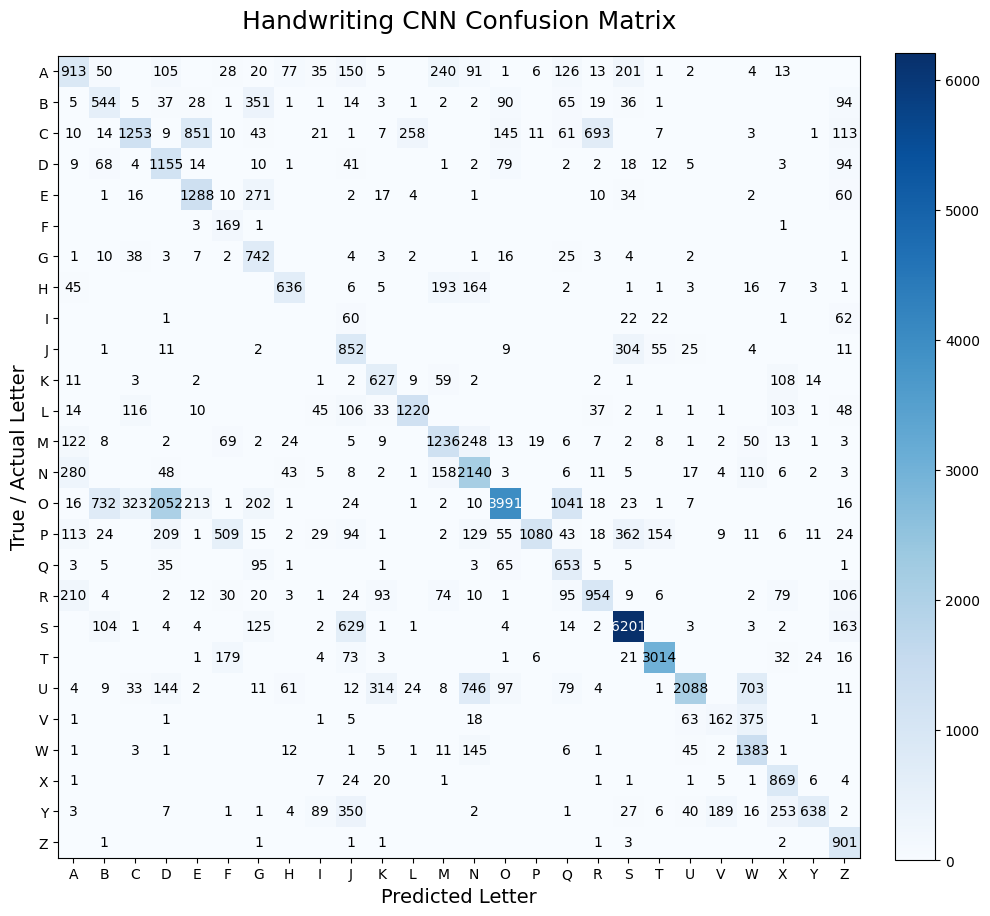

In [76]:
cm = confusion_matrix(labels, predictions_b)

# 2. Set up the figure size
fig, ax = plt.subplots(figsize=(10, 10))

# 3. Draw the heatmap blocks
# cmap=plt.cm.Blues makes it dark blue for high numbers, white for low numbers
cax = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
fig.colorbar(cax, fraction=0.046, pad=0.04) # Adds the color scale on the right

# 4. Set up the A-Z labels on the X and Y axes
classes = [chr(i + 65) for i in range(26)] # Generates ['A', 'B', 'C' ... 'Z']
tick_marks = np.arange(len(classes))

ax.set_xticks(tick_marks)
ax.set_yticks(tick_marks)
ax.set_xticklabels(classes)
ax.set_yticklabels(classes)

# 5. Add the numbers inside the boxes
# We calculate a threshold so we can use white text on dark blue boxes, 
# and black text on light blue boxes for readability.
thresh = cm.max() / 2.0

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        # Optional: Only draw the number if it's greater than 0 to keep the grid clean
        if cm[i, j] > 0:
            ax.text(j, i, format(cm[i, j], 'd'),
                    ha="center", va="center",
                    color="white" if cm[i, j] > thresh else "black")

# 6. Add the final titles and labels
ax.set_title('Handwriting CNN Confusion Matrix', fontsize=18, pad=20)
ax.set_ylabel('True / Actual Letter', fontsize=14)
ax.set_xlabel('Predicted Letter', fontsize=14)

# 7. Clean up the layout and display
fig.tight_layout()
plt.show()